# 12 — Parameter-scan analysis

Analyses the Latin-hypercube scan produced by `param_scan.py` / `param_scan.sh`. Each cluster
array task writes `<prefix>_seed_<N>.npy`, an `(n_samples, 6)` array:

| col | quantity | sampled range |
|-----|----------|---------------|
| 0 | `kappa_acc` (linear) | [0.01, 15] |
| 1 | `log10(m_acc / GeV)` | [11, 18] |
| 2 | `log10(f_acc)` (f ∈ 1e-4…1) | [-4, 0] |
| 3 | `log10(a_t_acc)` (a_t ∈ 1e-3…1) | [-3, 0] |
| 4 | `chi2_Cl` — CV-weighted χ² of ΔC_ℓ^TT (ℓ=2–2000, f_sky=0.75) | — |
| 5 | `dev_Pk` — max relative \|ΔP(k)\| (k∈[1e-4, 1] h/Mpc) | — |

Cols 1–3 are stored as the **raw log10** sampled values, so plot against them on a linear axis.
Each cosmology also carries 3 degenerate massive neutrinos (0.02 eV each) as the first ncdm
species; the accDM daughter is the second (last) species.

**C_ℓ metric (col 4):** a cosmic-variance-weighted χ², `Σ_ℓ (2ℓ+1)/2 · f_sky · (ΔC_ℓ/C_ℓ)²`, not a
relative deviation — coherent error accumulates, incoherent acoustic-trough noise averages out, and
it maps onto "does this bias the likelihood" (pass ≈ χ² < 0.1). **Requires data from the updated
`param_scan.py`**; older `.npy` stored `max|ΔC/C|` in this column. A failed CLASS run (crash /
unphysical cosmology) is stored as `NaN` in cols 4–5 with its parameters intact, so crash locations
stay mappable.

Goal: (a) quantify overall agreement, (b) locate **where** in parameter space the cheap config
breaks down. Set `SCAN_DIR` / `PREFIX` in the next cell to your output location.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 300})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# --- EDIT ME: where the .npy files live, and the prefix used at submit time ---
SCAN_DIR = Path('accDM_scans/fluid10001_vs_exact10001/')
# PREFIX   = 'fluid251_trig10_vs_exact1001'
# PREFIX   = 'exact10001_vs_exact5001'
# PREFIX   = 'fluid551_trig10_amp1.2_vs_exact1001'
PREFIX  = 'fluid10001_vs_exact10001'

files = sorted(SCAN_DIR.glob(f'{PREFIX}_sesed_*.npy'))
assert files, f'No files matching {PREFIX}_seed_*.npy in {SCAN_DIR}'
raw = np.concatenate([np.load(f) for f in files], axis=0)
# print(raw)
print(f'Loaded {len(files)} seed file(s) -> {raw.shape[0]} samples total')

# Column legend (matches param_scan.py results layout). Cols 1-3 are stored as the
# raw log10 sampled values: log10(m/GeV), log10(f_acc), log10(a_t_acc). kappa is linear.
# Col 4 (CHI2_CL) = cosmic-variance-weighted chi^2 of the C_l^TT deviation (Planck-like
# f_sky, ell<=2000) -- NOT a relative deviation. Needs data from the UPDATED param_scan.py;
# older .npy stored max|dC/C| in this column instead.
KAPPA, LOGM, FACC, AT, CHI2_CL, DEV_PK = range(6)
PARAM_COLS  = [KAPPA, LOGM, FACC, AT]
PARAM_LABEL = {KAPPA: r'$\kappa_{\rm acc}$', LOGM: r'$\log_{10}(m_{\rm acc}/{\rm GeV})$',
               FACC: r'$\log_{10} f_{\rm acc}$', AT: r'$\log_{10} a_{t,\rm acc}$'}

# Split successes from failed (NaN) runs; failed runs keep their parameters
finite = np.isfinite(raw[:, CHI2_CL]) & np.isfinite(raw[:, DEV_PK])
ok   = raw[finite]
# print(ok)
fail = raw[~finite]
print(f'  succeeded: {ok.shape[0]}   failed/NaN: {fail.shape[0]}   '
      f'success rate: {100*ok.shape[0]/raw.shape[0]:.1f}%')
if ok.shape[0]:
    print(f'  P(k) dev:    median {np.median(ok[:, DEV_PK]):.2e}   max {ok[:, DEV_PK].max():.2e}')
    print(f'  C_l CV-chi2: median {np.median(ok[:, CHI2_CL]):.2e}   max {ok[:, CHI2_CL].max():.2e}')

Loaded 100 seed file(s) -> 100 samples total
  succeeded: 100   failed/NaN: 0   success rate: 100.0%
  P(k) dev:    median 1.62e-03   max 3.85e-01
  C_l CV-chi2: median 6.12e-07   max 5.94e-01


In [26]:
# # --- Region-of-interest cut: restrict analysis to a subvolume ---
# # Columns: KAPPA, LOGM, FACC, AT.  NOTE: FACC and AT are stored as log10!
# ok_all, fail_all = ok, fail            # keep the unfiltered sets

# def in_region(a):
#     m = np.ones(len(a), dtype=bool)
#     m &= a[:, KAPPA] > 1.0             # kappa > 1
#     # m &= a[:, KAPPA] < 10.0            # kappa < 10
#     m &= a[:, FACC] < np.log10(0.01)  # e.g. f_acc > 0.1   (log10 threshold!)
#     # m &= a[:, AT]   < np.log10(0.1)  # e.g. a_t  < 0.1
#     return m

# ok   = ok_all[in_region(ok_all)]
# fail = fail_all[in_region(fail_all)]
# print(f'region: {ok.shape[0]} ok / {fail.shape[0]} failed '
#       f'(of {ok_all.shape[0]} / {fail_all.shape[0]})')

## Overall error distributions

Histograms (log10 axis) across all successful samples, with median / 95th-percentile markers.
Left: **P(k)** max relative deviation, with 1% and 5% reference lines. Right: **C_ℓ^TT**
cosmic-variance-weighted χ², with 0.1 (pass) and 1 (marginal) reference lines.

Orange lines: P(k) at 1% / 5%; C_l CV-chi2 at 0.1 (pass) / 1 (marginal).


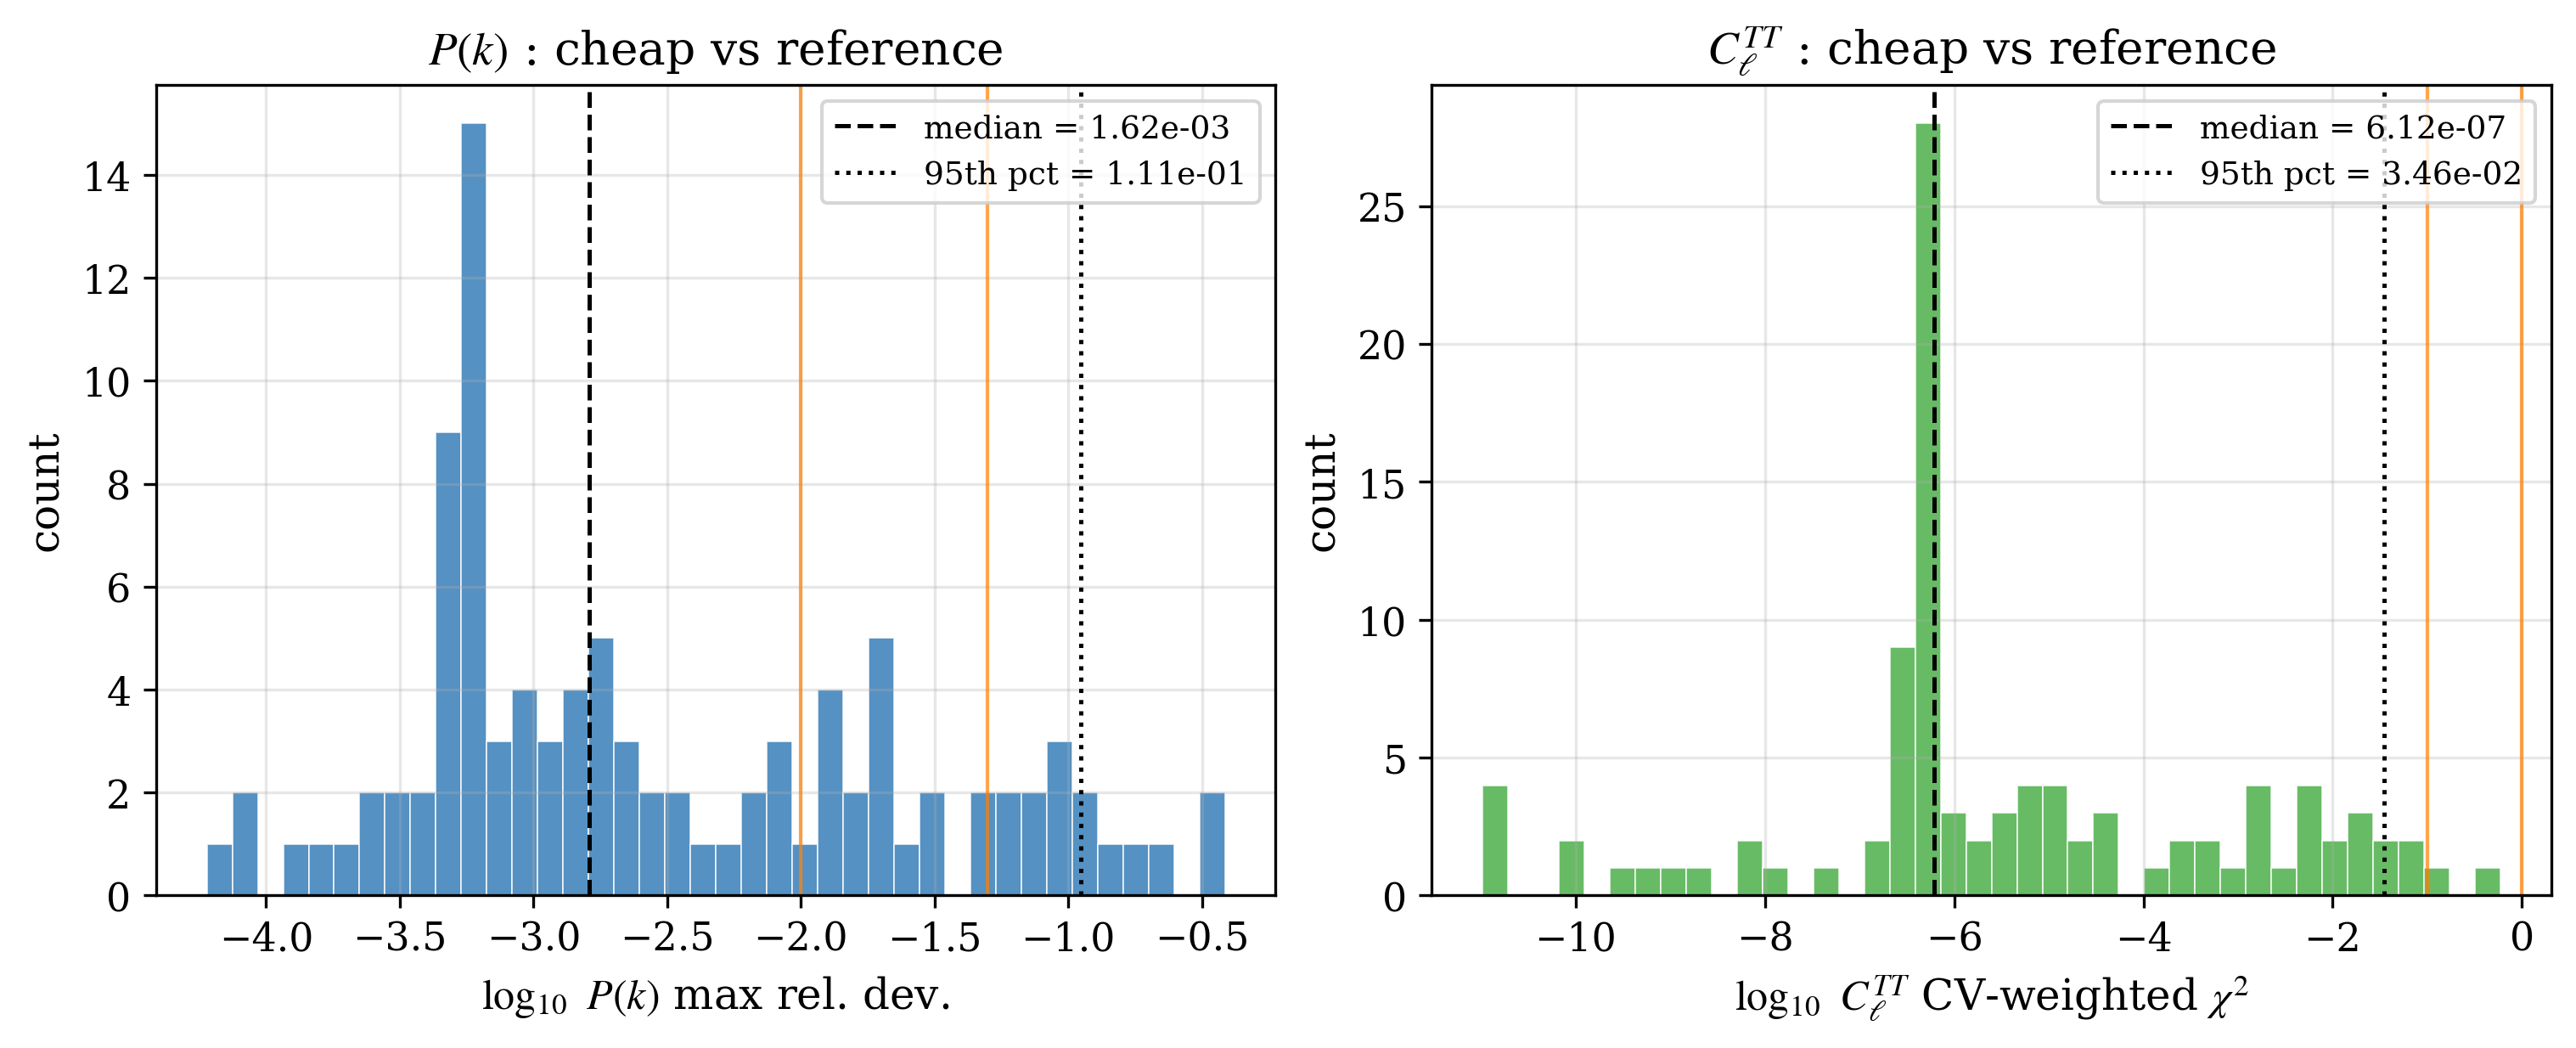

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
# (column, short title, x-label, color, threshold lines)
panels = [(DEV_PK,  r'$P(k)$',        r'$P(k)$ max rel. dev.',           qual_colors[0], (0.01, 0.05)),
          (CHI2_CL, r'$C_\ell^{TT}$', r'$C_\ell^{TT}$ CV-weighted $\chi^2$', qual_colors[2], (0.1, 1.0))]
for ax, (col, short, xlab, c, thrs) in zip(axes, panels):
    d = ok[:, col]
    d = d[d > 0]
    ax.hist(np.log10(d), bins=40, color=c, alpha=0.85, edgecolor='white', linewidth=0.4)
    med = np.median(d); p95 = np.percentile(d, 95)
    ax.axvline(np.log10(med), color='black', ls='--', lw=1.2, label=f'median = {med:.2e}')
    ax.axvline(np.log10(p95), color='black', ls=':',  lw=1.2, label=f'95th pct = {p95:.2e}')
    for thr in thrs:
        ax.axvline(np.log10(thr), color=qual_colors[1], ls='-', lw=1.0, alpha=0.7)
    ax.set_xlabel(r'$\log_{10}$ ' + xlab)
    ax.set_ylabel('count')
    ax.set_title(short + ' : cheap vs reference')
    ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
print('Orange lines: P(k) at 1% / 5%; C_l CV-chi2 at 0.1 (pass) / 1 (marginal).')
plt.show()

## Deviation vs each parameter

One-dimensional projections (log y) against each of the four scanned parameters: **P(k)** max
relative deviation (top, dashed = 1%) and **C_ℓ^TT** CV-weighted χ² (bottom, dashed = 0.1).
Trends reveal which knob drives the disagreement.

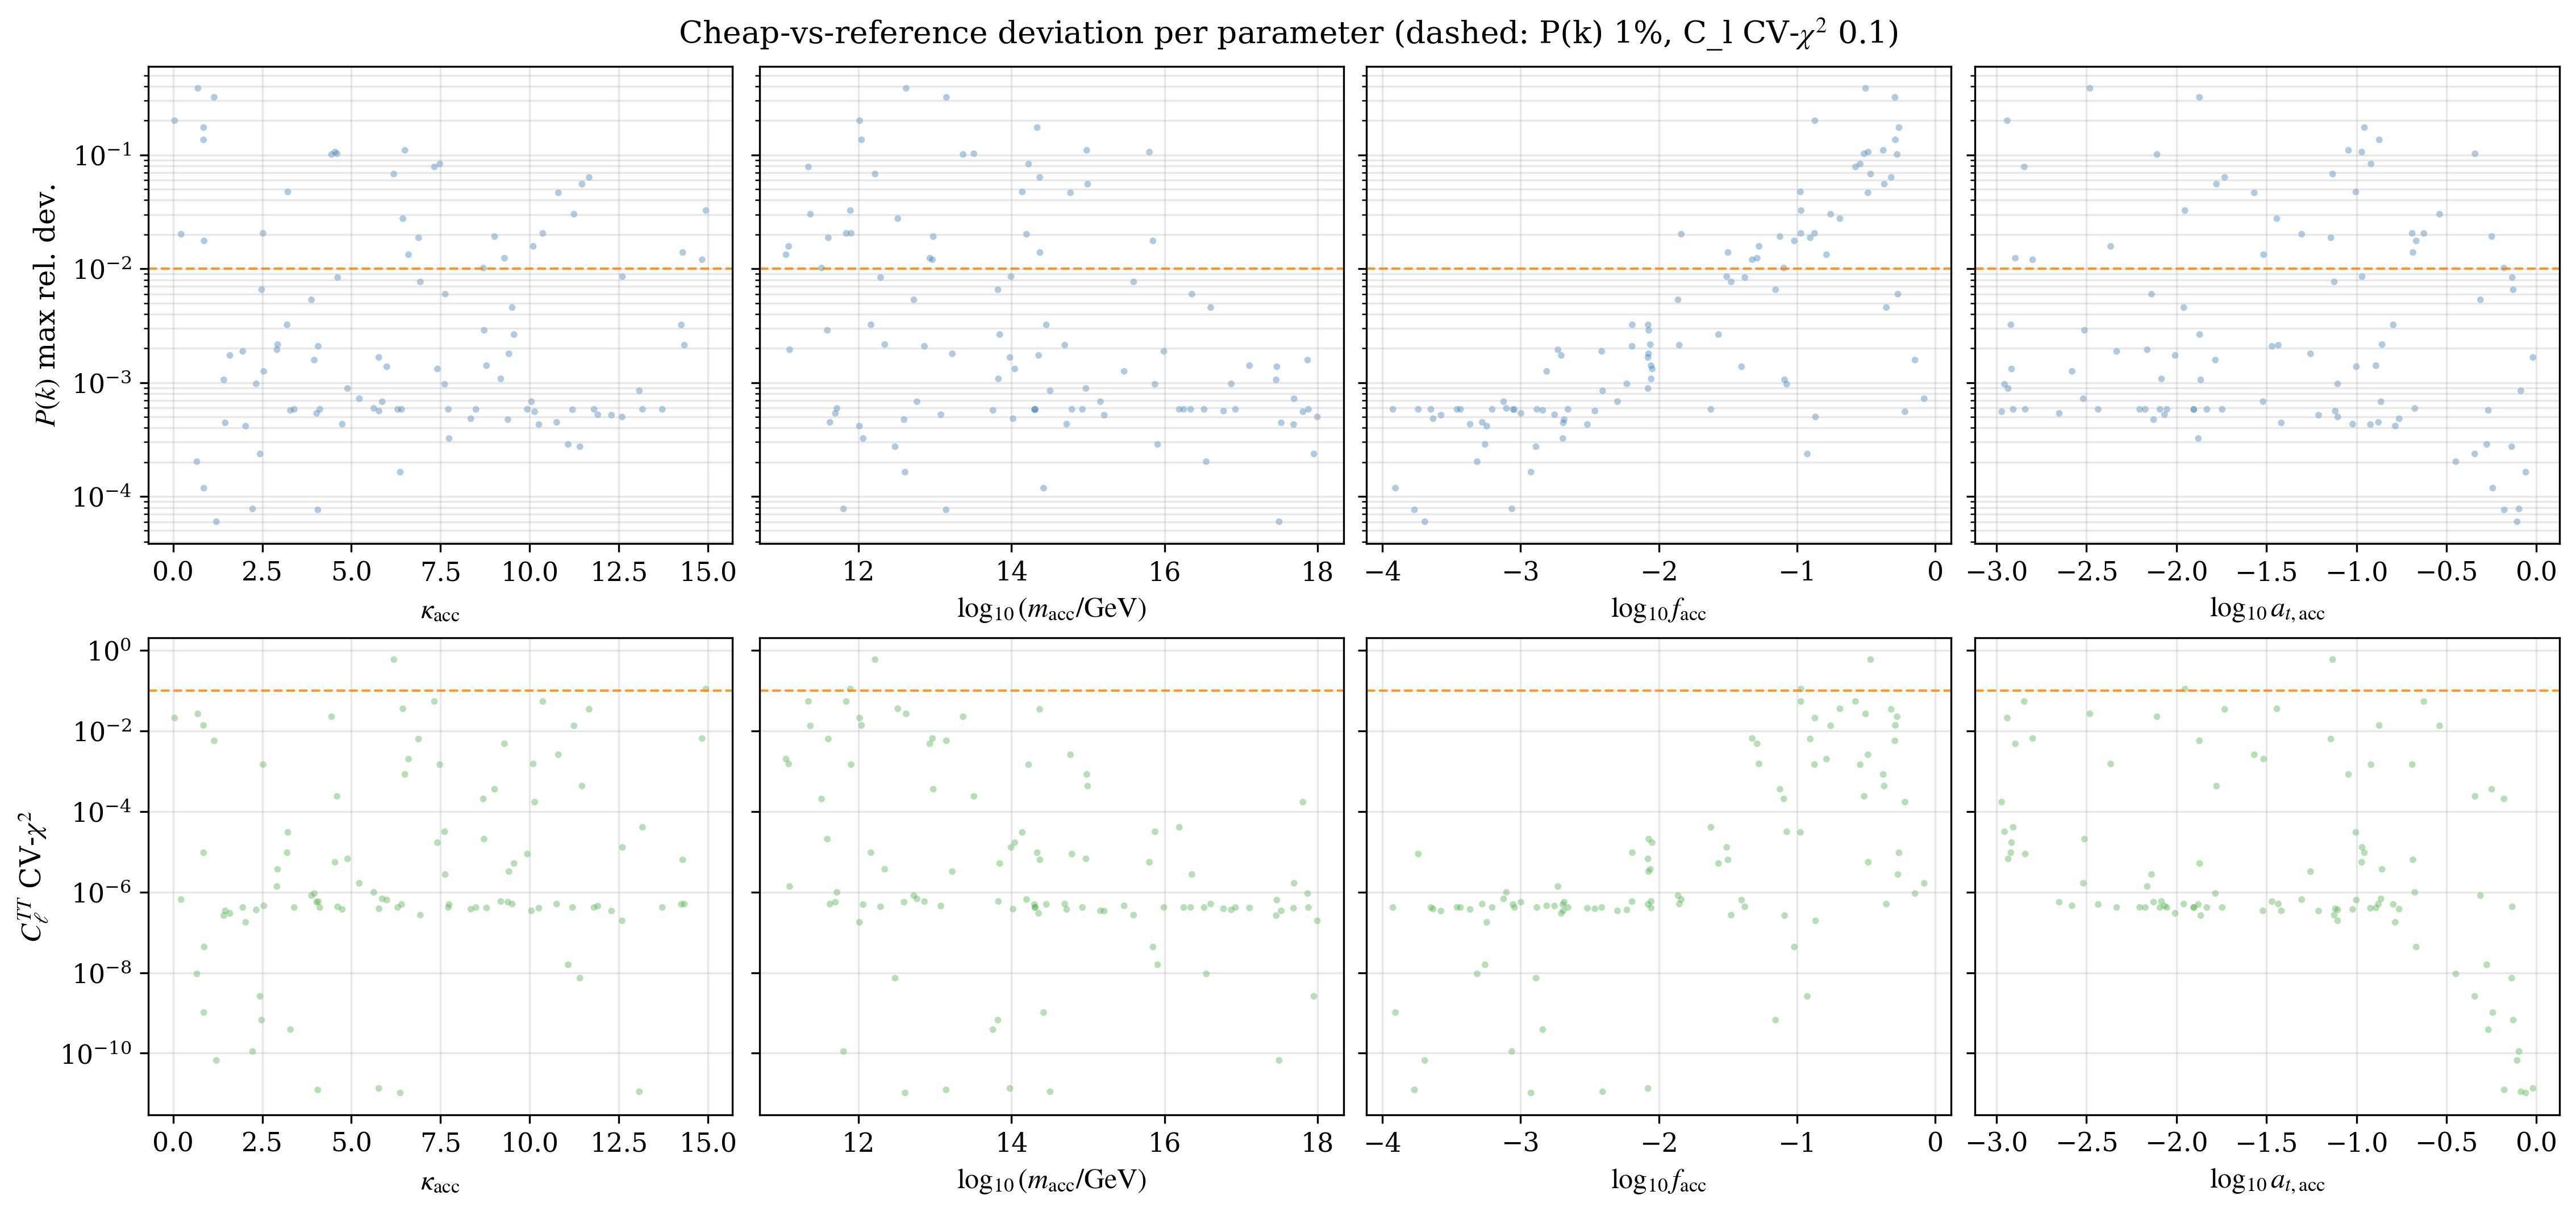

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True, sharey='row')
# (column, y-label, color, threshold line)
rows = [(DEV_PK,  r'$P(k)$ max rel. dev.',      qual_colors[0], 0.01),
        (CHI2_CL, r'$C_\ell^{TT}$ CV-$\chi^2$', qual_colors[2], 0.1)]
for row, (col, name, c, thr) in enumerate(rows):
    for j, pc in enumerate(PARAM_COLS):
        ax = axes[row, j]
        ax.scatter(ok[:, pc], ok[:, col], s=8, color=c, alpha=0.4, edgecolors='none')
        ax.set_yscale('log')
        ax.axhline(thr, color=qual_colors[1], ls='--', lw=1.0, alpha=0.8)
        ax.set_xlabel(PARAM_LABEL[pc])
        if j == 0:
            ax.set_ylabel(name)
        ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Cheap-vs-reference deviation per parameter (dashed: P(k) 1%, C_l CV-$\\chi^2$ 0.1)')
plt.show()

## Parameter-plane maps (the accDM-specific knobs)

`kappa_acc` (conversion sharpness) and `a_t_acc` (conversion epoch) set the daughter switch-on,
so the largest deviations and any crashes should concentrate in this plane. Color = max P(k)
deviation (log scale); ✕ = failed runs.

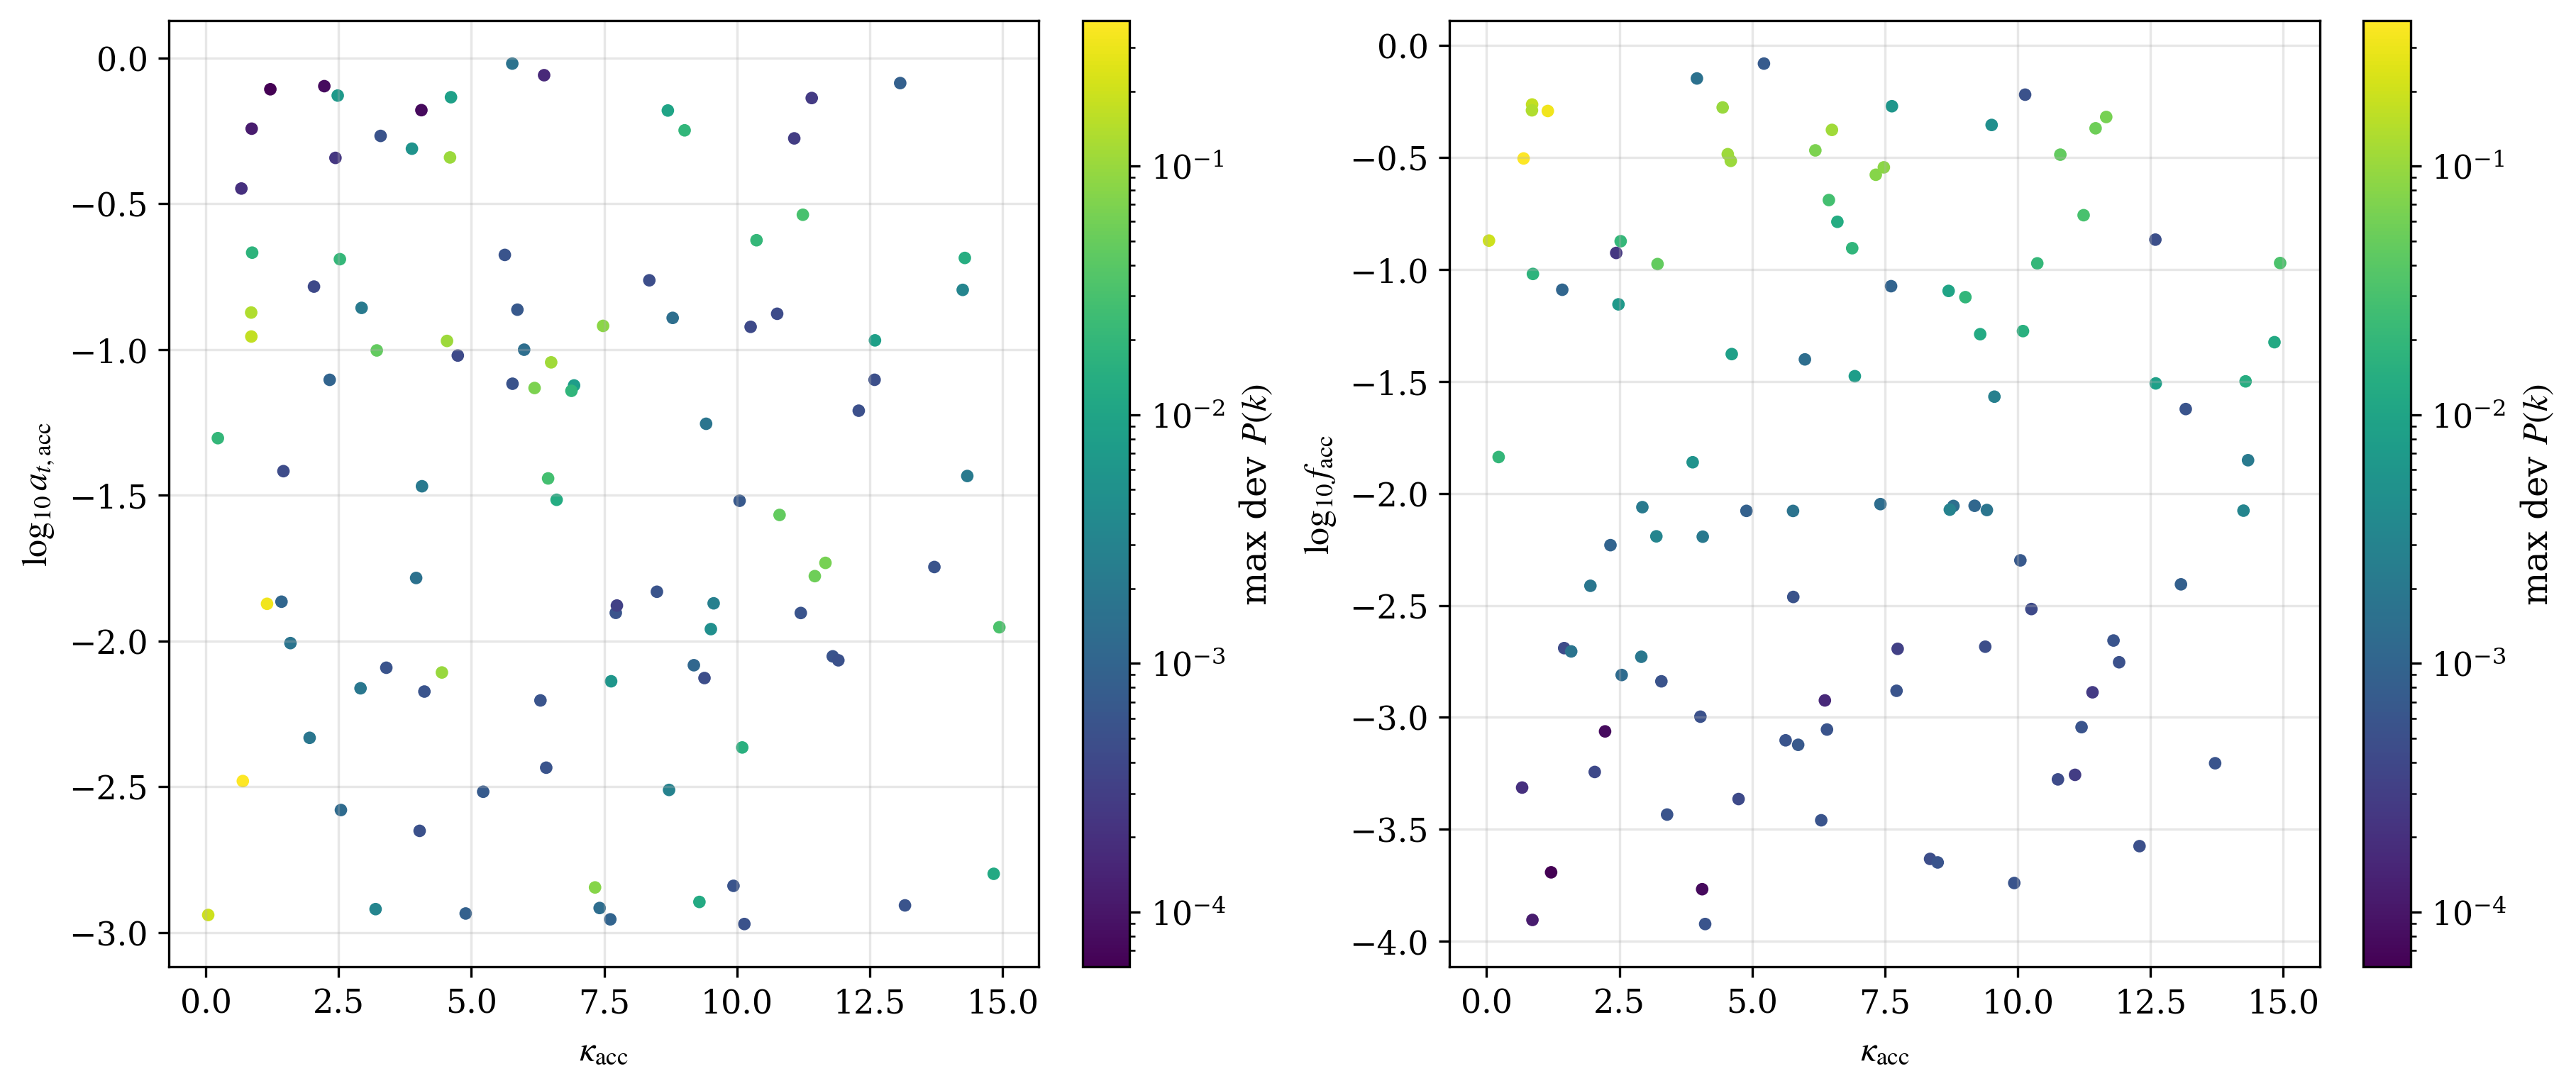

In [29]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pairs = [(KAPPA, AT), (KAPPA, FACC)]
for ax, (cx, cy) in zip(axes, pairs):
    sc = ax.scatter(ok[:, cx], ok[:, cy], c=ok[:, DEV_PK], s=18,
                    cmap='viridis', norm=LogNorm(), edgecolors='none')
    if fail.shape[0]:
        ax.scatter(fail[:, cx], fail[:, cy], marker='x', s=40,
                   color=qual_colors[3], label='failed run')
        ax.legend(loc='best')
    ax.set_xlabel(PARAM_LABEL[cx]); ax.set_ylabel(PARAM_LABEL[cy])
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax, label=r'max dev $P(k)$')
plt.show()

## Pass/fail at tolerance + worst offenders

Fraction of runs within a target P(k) tolerance, the 10 worst-deviating cosmologies, and how
the pass rate falls off with `kappa_acc` (the main switch-on-stiffness driver).

Within 1% P(k):           69/100 (69.0%)
C_l CV-chi2 < 0.1:            98/100 (98.0%)

Worst 10 by P(k) deviation:
  kappa  log10 m  log10 f  log10 a_t     dev_Pk    chi2_Cl
  0.697   12.624   -0.504     -2.481   3.85e-01   2.67e-02
  1.153   13.150   -0.292     -1.873   3.21e-01   5.72e-03
  0.045   12.016   -0.871     -2.940   2.00e-01   2.10e-02
  0.857   14.337   -0.263     -0.956   1.74e-01   9.51e-06
  0.855   12.041   -0.289     -0.873   1.36e-01   1.38e-02
  6.502   14.985   -0.376     -1.044   1.10e-01   8.37e-04
  4.541   15.803   -0.485     -0.971   1.06e-01   5.53e-06
  4.598   13.510   -0.515     -0.341   1.02e-01   2.39e-04
  4.445   13.368   -0.276     -2.108   1.01e-01   2.27e-02
  7.479   14.225   -0.543     -0.919   8.32e-02   1.46e-03


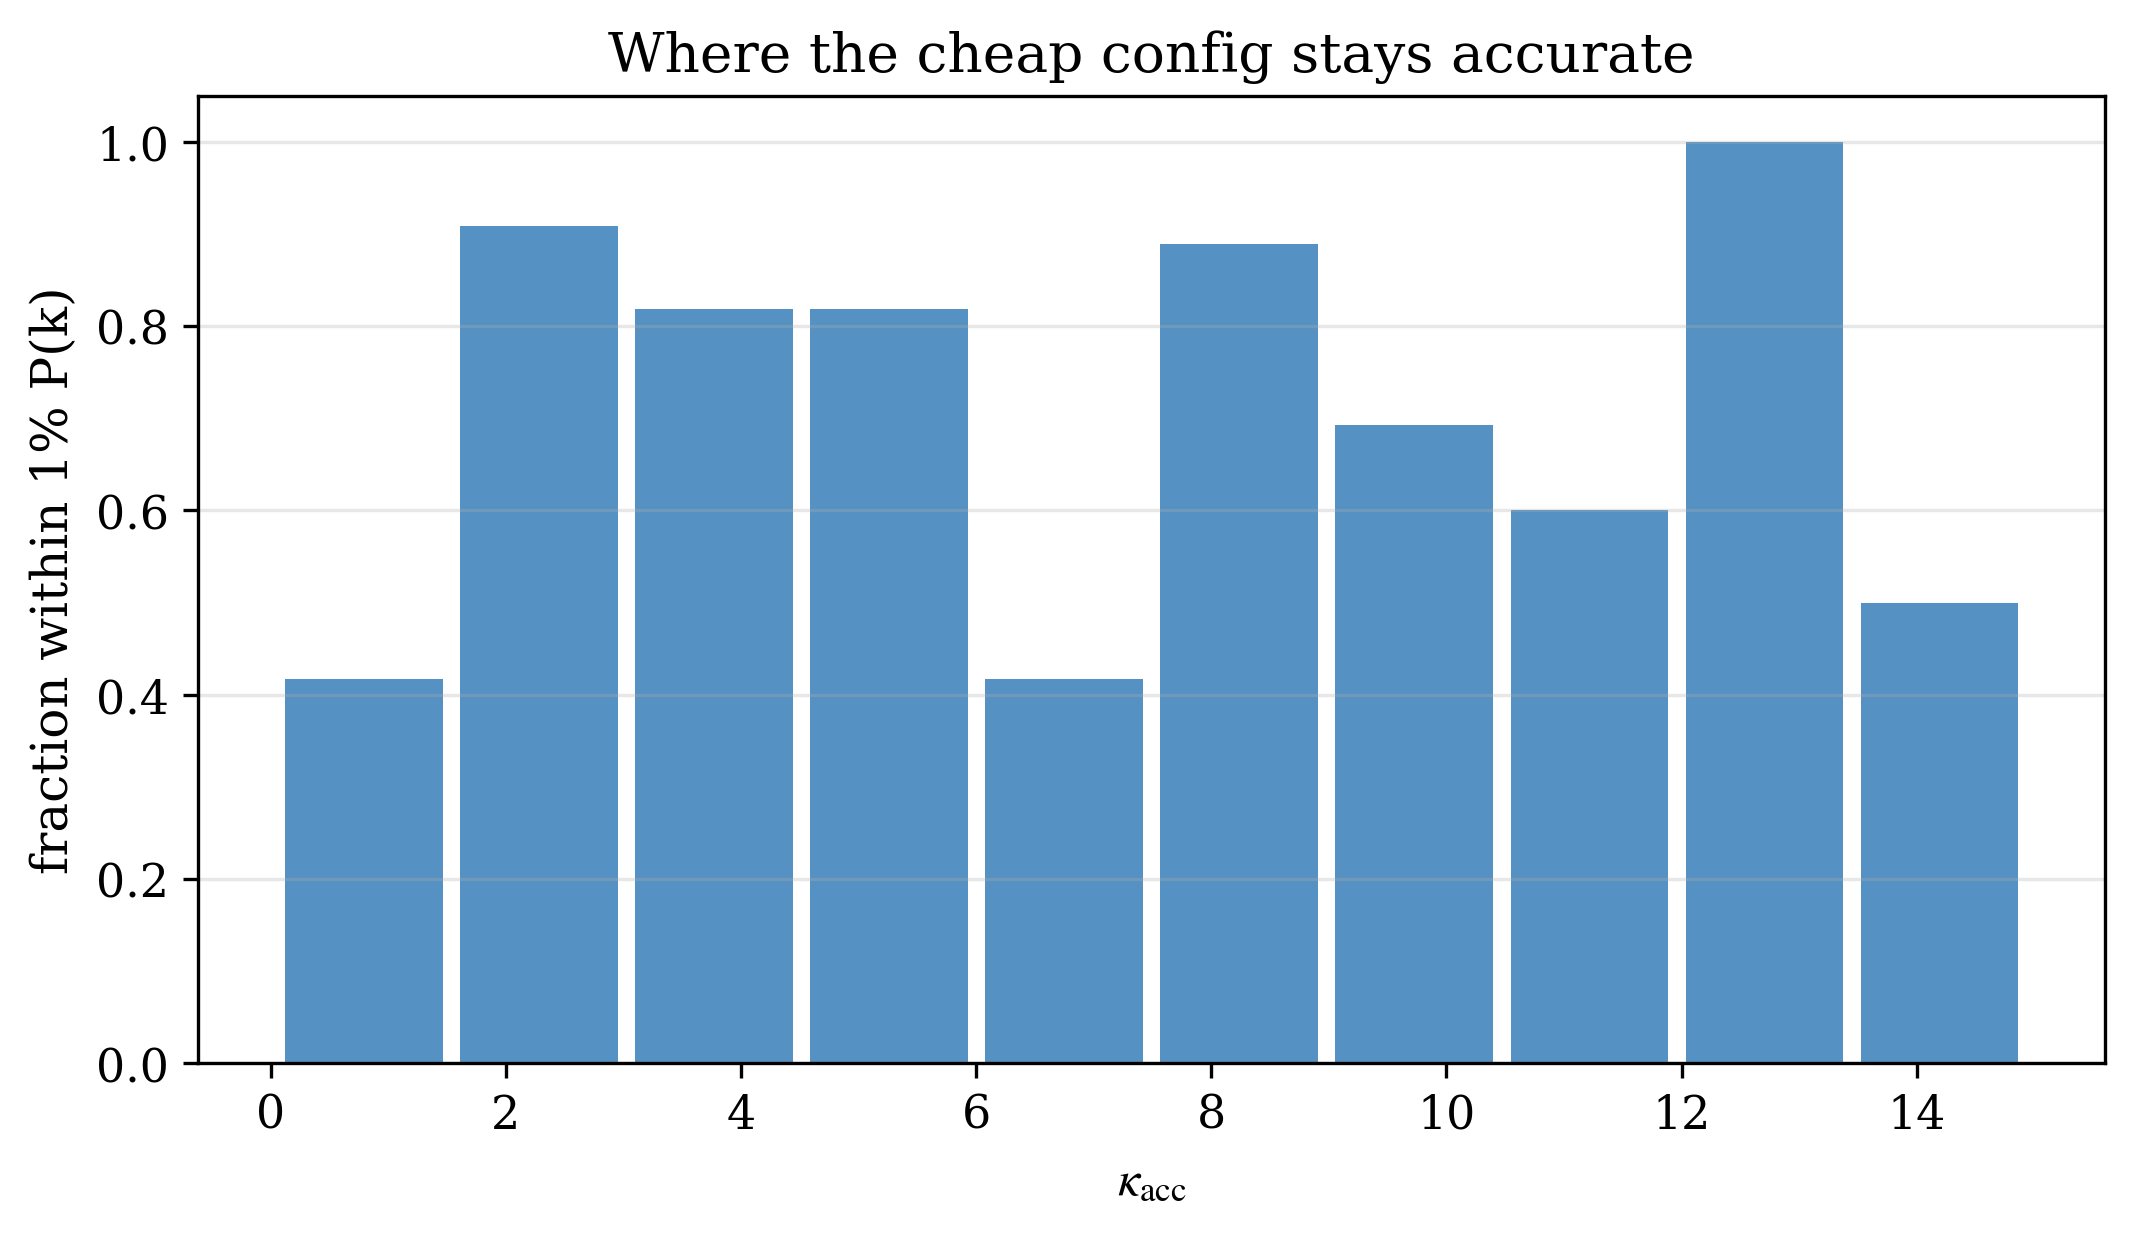

In [30]:
TOL_PK   = 0.01   # 1% P(k) target (max relative)
TOL_CHI2 = 0.1    # CV-weighted chi^2 target for C_l^TT (well sub-sigma)

pass_pk = ok[:, DEV_PK]  < TOL_PK
pass_cl = ok[:, CHI2_CL] < TOL_CHI2
print(f'Within {TOL_PK:.0%} P(k):           {pass_pk.sum()}/{ok.shape[0]} ({100*pass_pk.mean():.1f}%)')
print(f'C_l CV-chi2 < {TOL_CHI2}:            {pass_cl.sum()}/{ok.shape[0]} ({100*pass_cl.mean():.1f}%)\n')

# Worst 10 offenders by P(k) deviation (f, a_t shown as log10, matching storage)
order = np.argsort(ok[:, DEV_PK])[::-1][:10]
print('Worst 10 by P(k) deviation:')
print(f"{'kappa':>7} {'log10 m':>8} {'log10 f':>8} {'log10 a_t':>10} {'dev_Pk':>10} {'chi2_Cl':>10}")
for r in order:
    row = ok[r]
    print(f'{row[KAPPA]:7.3f} {row[LOGM]:8.3f} {row[FACC]:8.3f} {row[AT]:10.3f} '
          f'{row[DEV_PK]:10.2e} {row[CHI2_CL]:10.2e}')

# Fraction passing the P(k) cut vs kappa (the dominant switch-on-stiffness driver)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
edges = np.linspace(ok[:, KAPPA].min(), ok[:, KAPPA].max(), 11)
binid = np.clip(np.digitize(ok[:, KAPPA], edges) - 1, 0, len(edges) - 2)
centers = 0.5 * (edges[:-1] + edges[1:])
frac = np.array([pass_pk[binid == b].mean() if np.any(binid == b) else np.nan
                 for b in range(len(centers))])
ax.bar(centers, frac, width=0.9 * (edges[1] - edges[0]), color=qual_colors[0], alpha=0.85)
ax.set_xlabel(PARAM_LABEL[KAPPA]); ax.set_ylabel(f'fraction within {TOL_PK:.0%} P(k)')
ax.set_ylim(0, 1.05); ax.set_title('Where the cheap config stays accurate')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

### Notes
- **Two error sources are bundled.** `dev_Pk`/`dev_Cl` mix the fluid-closure error with the
  251→1001 momentum-grid coarsening (~0.4% P(k) floor on its own — notebook 10). A near-uniform
  ~0.4–1% floor across parameter space is the grid; structure *above* it (correlated with
  `kappa`/`a_t`) is the fluid closure. To isolate the two, add an exact-at-q=251 arm to the scan.
- **Expect the worst agreement at high `kappa` and small `a_t`** — sharper, earlier conversion is
  where the daughter fluid switch-on is most strained. The kappa-binned bar quantifies the usable
  boundary.
- **Failed (`NaN`) runs** are drawn as ✕ in the parameter-plane maps; clustering there flags a
  region where even `trigger=10` is too stiff for `rk`, or an unphysical cosmology.
- Adjust `TOL_PK` to your science requirement; 1% is a reasonable target given the grid floor.
- nbmake: `pytest --nbmake notebooks_test/12_test_param_scan_analysis.ipynb` (needs the `.npy`
  files present at `SCAN_DIR`).